### Importação das bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

### Carregamento dos dados

In [32]:

df = pd.read_csv("../data/vendas_2023_2024.csv", index_col="id")

In [33]:
df.head(10)

,id_client,id_product,qtd,total,sale_date
id,,,,,
0,42,105,11,3405.00,2023-09-10
1,3,136,9,16873.90,15-09-2024
2,25,139,7,9475.30,2024-08-13
4,20,23,5,55893.00,2023-02-03
5,8,57,4,451403.90,2024-02-12
6,36,52,3,39056.40,2023-09-26
8,27,25,3,34560.05,2024-02-28
9,37,26,7,114932.90,07-11-2023
10,31,143,3,12643.55,2024-08-25


<span style="color:red">**Atenção**!!! *(Data com formato diferente)*</span>

In [34]:
fmt1 = df['sale_date'].str.match(r'^\d{4}-\d{2}-\d{2}$') 
fmt2 = df['sale_date'].str.match(r'^\d{2}-\d{2}-\d{4}$') 
fmt3 = ~fmt1 & ~fmt2                                       

print("Contagem de registro para cada tipo de Data:")
print("YYYY-MM-DD: ", fmt1.sum())
print("DD-MM-YYYY: ", fmt2.sum())
print("Desconhecido:", fmt3.sum())

Contagem de registro para cada tipo de Data:
YYYY-MM-DD:  4913
DD-MM-YYYY:  4982
Desconhecido: 0


### Visão geral do dataset

In [35]:
df.info()

<class 'pandas.DataFrame'>
Index: 9895 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_client   9895 non-null   int64  
 1   id_product  9895 non-null   int64  
 2   qtd         9895 non-null   int64  
 3   total       9895 non-null   float64
 4   sale_date   9895 non-null   str    
dtypes: float64(1), int64(3), str(1)
memory usage: 463.8 KB


In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
print("Menor data encontrada:")
df['sale_date'].min()

Menor data encontrada:


'01-01-2023'

In [38]:
print("Maior data encontrada:")
df['sale_date'].max()

Maior data encontrada:


'31-12-2024'

### Análise de valores numéricos

In [39]:
df.describe().round(2)

,id_client,id_product,qtd,total
count,9895.00,9895.00,9895.00,9895.00
mean,24.87,75.26,8.02,263797.83
std,14.18,43.53,4.30,390007.18
min,1.00,1.00,1.00,294.50
25%,13.00,37.00,4.00,23138.20
50%,25.00,74.00,8.00,82225.00
75%,37.00,114.00,12.00,339094.50
max,49.00,150.00,15.00,2222973.00


<span style="color:red">**Atenção**!!! *(Média (263797.83) e Mediana (82225.00) com valores consideravelmente diferentes na coluna "total", isso indica outliers)*</span>

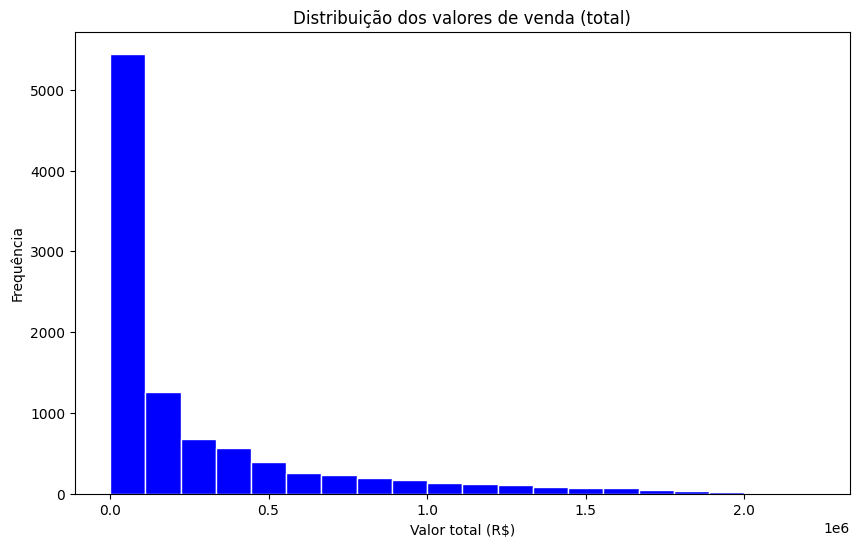

In [40]:
plt.figure(figsize=(10,6))
plt.hist(df['total'], bins=20, color='blue', edgecolor='white')
plt.title('Distribuição dos valores de venda (total)')
plt.xlabel('Valor total (R$)')
plt.ylabel('Frequência')
plt.show()

Visualmente conseguimos ter mais clareza, a frequência de ocorrência para valores muito alto é mínima

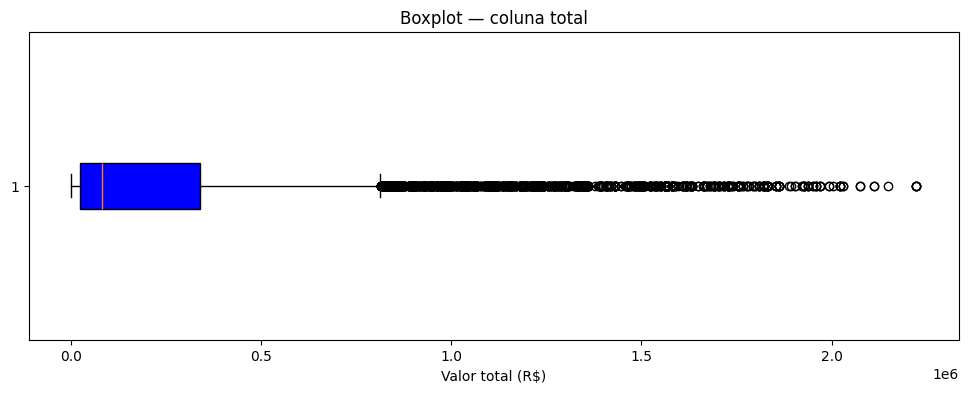

In [41]:
plt.figure(figsize=(12, 4))
plt.boxplot(df['total'], vert=False, patch_artist=True, boxprops=dict(facecolor='blue'))
plt.title('Boxplot — coluna total')
plt.xlabel('Valor total (R$)')
plt.show()

Pelo boxplot vemos que temos diversos outliers

In [42]:
Q1 = df['total'].quantile(0.25)
Q3 = df['total'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['total'] < limite_inferior) | (df['total'] > limite_superior)]

print(f"Limite inferior: R$ {limite_inferior:,.2f}")
print(f"Limite superior: R$ {limite_superior:,.2f}")
print(f"Total de outliers: {len(outliers)}")
outliers.sort_values('total', ascending=False)

Limite inferior: R$ -450,796.25
Limite superior: R$ 813,028.95
Total de outliers: 1018


,id_client,id_product,qtd,total,sale_date
id,,,,,
9000,47,76,15,2222973.0,2023-04-30
3911,39,76,15,2222973.0,07-08-2023
9727,22,76,15,2222973.0,2024-07-08
1598,9,76,15,2222973.0,2024-07-19
8017,43,73,15,2147399.0,2023-10-12
...,...,...,...,...,...
9635,7,67,10,814995.5,18-05-2023
4668,42,67,10,814995.5,26-12-2024
1497,37,67,10,814995.5,10-12-2023


<span style="color:purple">**Recomendação**!!! *(Esses valores repetidos são bem estranhos, acho importante ter uma conversa com a Marina Costa (Gerente de Negócios) para verificar a integridade desses outliers e pedir orientação para possiveis ajustes)*</span>